# Unsupervised Learning

PCA and K-Means on the Wine dataset.

Question: without being given the labels, can clustering recover the
real structure in the data?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.ensemble import IsolationForest

RANDOM_STATE = 42

In [2]:
data = load_wine(as_frame=True)

X = data.data
y_true = data.target      # kept ONLY for checking afterwards

print("Shape:", X.shape)
print("\nSummary:")
print(X.describe().T[["mean", "std", "min", "max"]])

Shape: (178, 13)

Summary:
                                    mean         std     min      max
alcohol                        13.000618    0.811827   11.03    14.83
malic_acid                      2.336348    1.117146    0.74     5.80
ash                             2.366517    0.274344    1.36     3.23
alcalinity_of_ash              19.494944    3.339564   10.60    30.00
magnesium                      99.741573   14.282484   70.00   162.00
total_phenols                   2.295112    0.625851    0.98     3.88
flavanoids                      2.029270    0.998859    0.34     5.08
nonflavanoid_phenols            0.361854    0.124453    0.13     0.66
proanthocyanins                 1.590899    0.572359    0.41     3.58
color_intensity                 5.058090    2.318286    1.28    13.00
hue                             0.957449    0.228572    0.48     1.71
od280/od315_of_diluted_wines    2.611685    0.709990    1.27     4.00
proline                       746.893258  314.907474  278.00  1

### Why scaling matters

The features are measured on very different scales. For example, proline
has values in the hundreds, while some other features are close to 1.

Scaling is therefore important for distance-based methods such as K-Means.
Without scaling, features with larger numerical values can dominate the
distance calculation.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (178, 13)
Scaled shape: (178, 13)


In [4]:
# K-Means on the raw, unscaled data
km_raw = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

raw_labels = km_raw.fit_predict(X)

# K-Means on the scaled data
km_scaled = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

scaled_labels = km_scaled.fit_predict(X_scaled)

# Compare both with the true labels
raw_ari = adjusted_rand_score(y_true, raw_labels)
scaled_ari = adjusted_rand_score(y_true, scaled_labels)

print(f"ARI without scaling: {raw_ari:.4f}")
print(f"ARI with scaling:    {scaled_ari:.4f}")

ARI without scaling: 0.3711
ARI with scaling:    0.8975


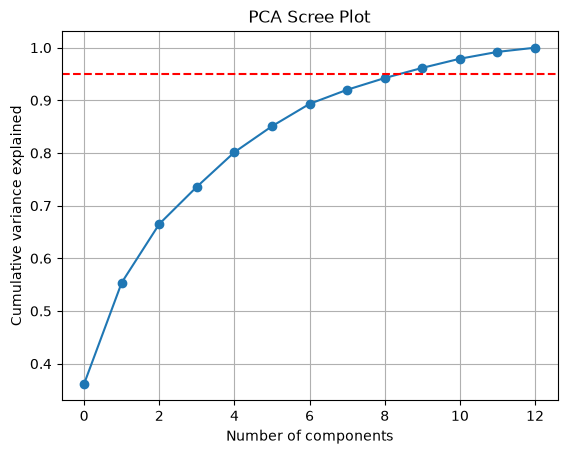

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294]


In [5]:
pca = PCA()
pca.fit(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.axhline(0.95, linestyle="--", color="red")
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance explained")
plt.title("PCA Scree Plot")
plt.grid(True)
plt.savefig("../reports/pca_scree.png", dpi=120, bbox_inches="tight")
plt.show()

print(pca.explained_variance_ratio_[:5])

### PCA findings

The first 5 principal components explain approximately 80.3% of the
total variance.

It takes 9 components to reach 95% cumulative explained variance.
Therefore, PCA reduces the 13 original features to 9 components while
retaining at least 95% of the information measured by variance.

The compression is useful, but it is not dramatic: 9 components are still
needed to preserve 95% of the variance.

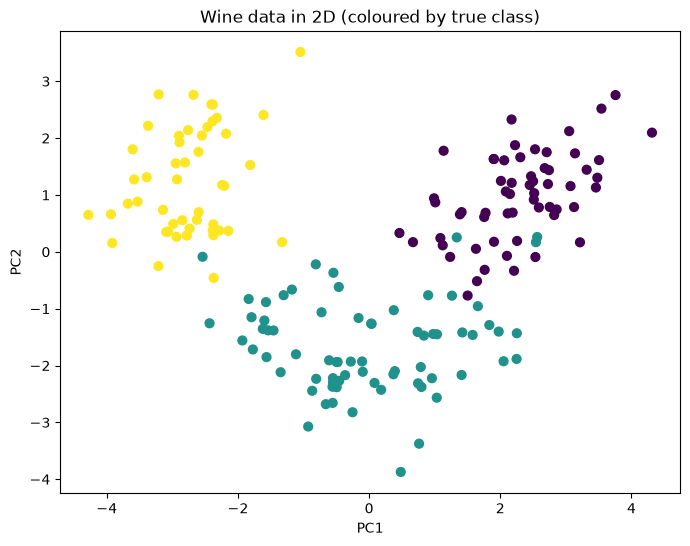

In [6]:
X_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_true,
    cmap="viridis",
    s=40
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine data in 2D (coloured by true class)")

plt.savefig(
    "../reports/pca_2d.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

### 2D PCA visualization

The first two principal components reduce the dataset from 13 features to
2 dimensions while retaining about 55.1% of the total variance.

Despite this substantial dimensionality reduction, the three true wine
classes remain visibly separated in the 2D projection. The separation is
not perfect, with some overlap between groups, but the overall structure
of the classes is clearly visible.

In [7]:
inertias = []
silhouettes = []

ks = range(2, 11)

for k in ks:
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    ).fit(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, km.labels_)
    )

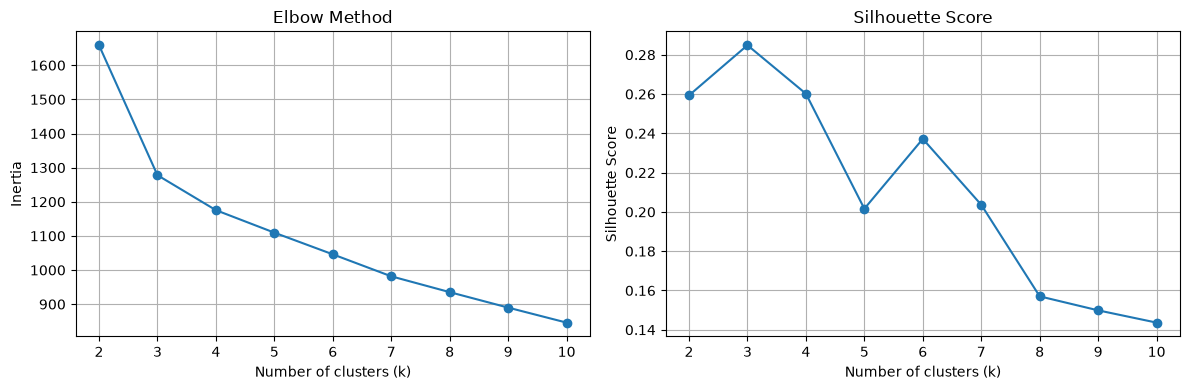

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow plot
axes[0].plot(ks, inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

# Silhouette plot
axes[1].plot(ks, silhouettes, marker="o")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")
axes[1].grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/elbow_silhouette.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()

### Choosing the number of clusters

The elbow method shows a large reduction in inertia when moving from
k=2 to k=3, followed by smaller improvements as more clusters are added.
The elbow therefore suggests k=3, although the bend is not perfectly
sharp.

The silhouette score provides stronger evidence: k=3 has the highest
silhouette score at approximately 0.285. Both methods therefore support
using 3 clusters, although the choice is not completely unambiguous.

Importantly, this decision was made without using the true class labels.

In [9]:
km3 = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
).fit(X_scaled)

ari = adjusted_rand_score(y_true, km3.labels_)

print("ARI vs true labels:", ari)

print("\nCluster vs true class:")
print(pd.crosstab(km3.labels_, y_true))

ARI vs true labels: 0.8974949815093207

Cluster vs true class:
target   0   1   2
row_0             
0        0  65   0
1        0   3  48
2       59   3   0


### K-Means results

K-Means with k=3 achieved an ARI of 0.8975 against the true labels,
indicating strong agreement between the discovered clusters and the real
wine classes.

The crosstab shows that the clusters correspond closely to the three true
classes. Cluster 0 contains all 65 samples from class 1, while cluster 2
contains 59 of the 62 samples from class 0. Cluster 1 contains 48 of the
48 samples from class 2, with only a small amount of mixing.

This is a strong result, especially because the true labels were not used
to create the clusters. They were used only afterwards to evaluate how
well K-Means recovered the existing structure.

In [10]:
eps_values = [1.5, 2.0, 2.5]

for eps in eps_values:
    db = DBSCAN(
        eps=eps,
        min_samples=5
    ).fit(X_scaled)

    labels = db.labels_

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise points={n_noise}"
    )

eps=1.5: clusters=0, noise points=178
eps=2.0: clusters=5, noise points=85
eps=2.5: clusters=1, noise points=24


### DBSCAN results

DBSCAN was highly sensitive to the choice of `eps`.

At `eps=1.5`, no clusters were found and all 178 points were classified
as noise. At `eps=2.0`, DBSCAN found 5 clusters but classified 85 points
as noise. At `eps=2.5`, the clusters merged into a single cluster with
24 points classified as noise.

This shows that DBSCAN's results can change dramatically with a small
change in a single parameter. Unlike K-Means, DBSCAN does not require the
number of clusters to be specified in advance, but choosing suitable
density parameters can be difficult.

In [11]:
agg = AgglomerativeClustering(
    n_clusters=3
).fit(X_scaled)

agg_ari = adjusted_rand_score(
    y_true,
    agg.labels_
)

print("Hierarchical clustering ARI:", agg_ari)

Hierarchical clustering ARI: 0.7899332213582837


### Hierarchical clustering

Agglomerative (hierarchical) clustering achieved an ARI of 0.7899,
compared with 0.8975 for K-Means.

K-Means therefore recovered the known wine classes more accurately in
this experiment. This result is specific to this dataset and these
settings; it does not mean K-Means is universally better than
hierarchical clustering.

In [12]:
iso = IsolationForest(
    contamination=0.05,
    random_state=RANDOM_STATE
).fit(X_scaled)

outliers = iso.predict(X_scaled) == -1

print("Outliers flagged:", outliers.sum())

Outliers flagged: 9


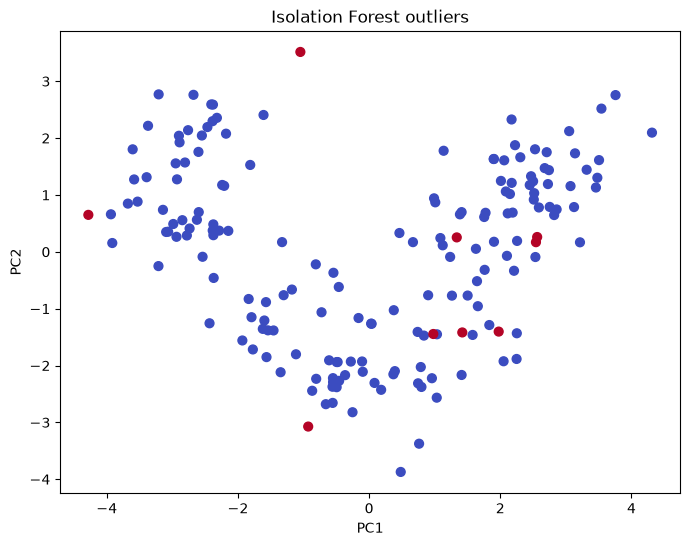

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=outliers,
    cmap="coolwarm",
    s=40
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest outliers")

plt.show()

### Isolation Forest

Isolation Forest flagged 9 observations as outliers, corresponding to
approximately 5% of the dataset as specified by the contamination
parameter.

The flagged points appear mostly around the edges of the main data
structure in the PCA projection. They are not concentrated in a single
wine class, which is expected because Isolation Forest identifies unusual
observations rather than trying to reproduce the known classes.

In [14]:
# Save key results
unsupervised_summary = pd.DataFrame({
    "method": [
        "K-Means (unscaled)",
        "K-Means (scaled)",
        "Hierarchical clustering"
    ],
    "ARI": [
        raw_ari,
        scaled_ari,
        agg_ari
    ]
})

unsupervised_summary.to_csv(
    "../reports/unsupervised_comparison.csv",
    index=False
)

unsupervised_summary

,method,ARI
0,K-Means (unscaled),0.371114
1,K-Means (scaled),0.897495
2,Hierarchical clustering,0.789933


## Conclusion

This notebook showed why preprocessing and evaluation choices matter in
unsupervised learning.

First, scaling had a dramatic effect on K-Means. Without scaling, the
Adjusted Rand Index (ARI) was 0.3711, while scaling increased it to 0.8975.
The large improvement demonstrates that distance-based clustering can be
dominated by features with larger numerical scales.

PCA reduced the 13 original features to 9 components while retaining
95% of the variance. The first two components retained about 55.1% of the
variance and still showed clear visual separation between the three true
wine classes.

When choosing the number of clusters without using the labels, the elbow
method suggested k=3, although the elbow was not perfectly sharp. The
silhouette score gave stronger evidence for k=3, with its highest score of
approximately 0.285.

K-Means with k=3 achieved an ARI of 0.8975 against the true labels. The
clusters corresponded closely to the actual wine classes, showing that
K-Means recovered much of the real structure without seeing the labels
during clustering.

Other methods produced different results. Hierarchical clustering
achieved an ARI of 0.7899, lower than K-Means on this dataset. DBSCAN was
highly sensitive to its eps parameter: eps=1.5 produced no clusters,
eps=2.0 produced 5 clusters with 85 noise points, and eps=2.5 produced
one cluster with 24 noise points. Isolation Forest flagged 9 observations
as outliers using a 5% contamination setting.

The final lesson is that unsupervised learning is difficult to evaluate
because real clustering problems usually do not provide ground-truth
labels. Here, the true labels allowed us to calculate ARI and check
whether the discovered structure corresponded to reality. In a real
unsupervised problem, that external check may not exist, so choices such
as scaling, the number of clusters, and algorithm parameters require much
more careful interpretation.

### The metric disagreed with the truth

The silhouette score at k=3 was only 0.285, which suggests weakly
separated clusters. But the ARI against the true labels was 0.8975,
meaning the clustering was almost exactly right.

This is the practical problem with unsupervised learning. In a real
problem there are no labels, so silhouette is the number you would act
on — and here it would have made you doubt a clustering that was
correct. Internal metrics measure geometric compactness, not whether
the clusters mean anything.